In [1]:
import torch
from torch import nn
from torch import optim
from torch.nn.utils import parameters_to_vector
from torch.nn.functional import gelu
# from torchvision import datasets, transforms

import torchattacks

import numpy as np
import matplotlib.pyplot as plt
# from tqdm import tqdm

from copy import deepcopy
# from itertools import permutations

from helpers import *

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# import matplotlib.animation as animation
# from matplotlib.colors import ListedColormap

from collections import deque
from torch.utils.data import TensorDataset, DataLoader

from sklearn.linear_model import LogisticRegression


In [50]:
%config InlineBackend.figure_format = 'png'
device = "mps"

# Use this for Windows
device = "cuda" if torch.cuda.is_available() else "cpu"

# Functions

In [3]:
def hypersphere_data_noisy(dim_in, dim_out, N_samples, batch_size, seed, eps=0.15):
    """
    Generates N-dimensional hypersphere problem data with random labels within some eps

    Unit vector directions are drawn from standard normal in dim_in dimensions.
    Then vectors are scaled uniformly by radius 0 < r < 1.
    Radii are assigned to dim_out even classes (e.g. dim_out = 2 gives classes (0,0.5), (0.5,1.0))

    Function returns DataLoader class containing generated samples.
    """
    torch.manual_seed(seed)

    u = torch.randn(N_samples, dim_in)
    u = u / torch.linalg.vector_norm(u, dim=1).unsqueeze(1)
    
    r = torch.rand(N_samples)
    
    data = u * r.unsqueeze(1) # Scale unit directions by radii

    bounds = torch.linspace(0, 1, dim_out+1)
    labels = torch.bucketize(r, bounds) - 1 # Evenly divide radii into classes

    for i in range(0,len(r)):
        # if r is within eps of its lower bound (not including 0)
        if abs(r[i]-bounds[labels[i]])< eps/dim_out and labels[i]!=0: 
            labels[i] = np.random.choice( [labels[i]-1,labels[i]] )
        # if r is within eps of its upper bound
        elif abs(r[i]-bounds[labels[i]+1])< eps/dim_out and labels[i]!=dim_out-1:
            labels[i] = np.random.choice( [labels[i],labels[i]+1] )
    
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(TensorDataset(data, labels), 
                      batch_size=batch_size, shuffle=True, generator=g)

In [4]:
def hypersphere_data_away_boundary(dim_in, dim_out, N_samples, batch_size, seed):
    """
    Generates N-dimensional hypersphere problem data that centers with normal distr 2.5*sigma away from boundary.
    !!!!!!NOT SURE IF THIS TYPE OF DATA MAKES ANY SENSE TO USE BUT JUST FOR THE SAKE OF 
    EXPERIMENTING THINGS...

    Unit vector directions are drawn from standard normal in dim_in dimensions.
    Then vectors are scaled uniformly by radius 0 < r < 1.
    Radii are assigned to dim_out even classes (e.g. dim_out = 2 gives classes (0,0.5), (0.5,1.0))

    Function returns DataLoader class containing generated samples.
    """
    torch.manual_seed(seed)

    u = torch.randn(N_samples, dim_in)
    u = u / torch.linalg.vector_norm(u, dim=1).unsqueeze(1)
    
    r = torch.empty(N_samples)
    b = N_samples // dim_out
    std = 1.0 / (dim_out * 5)  # Boundaries are 2.5 std away from the mean
    for d in range(dim_out):
        start_idx = d * b
        end_idx = (d + 1) * b if d < dim_out - 1 else N_samples
        count = end_idx - start_idx
        
        mean = (2 * d + 1) / (2 * dim_out)  # Class midpoint
        
        # Draw normal samples; clamp to strictly stay within class boundaries [d/dim_out, (d+1)/dim_out]
        samples = torch.randn(count) * std + mean
        lower_bound = d / dim_out
        upper_bound = (d + 1) / dim_out
        
        # Clamping prevents rare tail samples from bleeding into neighboring classes
        r[start_idx:end_idx] = torch.clamp(samples, min=lower_bound + 1e-6, max=upper_bound - 1e-6)
    
    data = u * r.unsqueeze(1) # Scale unit directions by radii
    labels = torch.bucketize(r, torch.linspace(0, 1, dim_out+1)) - 1 # Evenly divide radii into classes
    
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(TensorDataset(data, labels), 
                      batch_size=batch_size, shuffle=True, generator=g)

In [8]:
def linear_circle_data(input_dim, output_dim, N_samples, batch_size, seed):
    """
    Generates points in unit circle assigned to 3 balanced classes separated by lines y = x ± 0.3747
    """
    torch.manual_seed(seed)

    u = torch.randn(N_samples, 2)
    u = u / torch.linalg.vector_norm(u, dim=1).unsqueeze(1)
    
    r = torch.sqrt(torch.rand(N_samples)) # Sqrt evenly distributes across the area
    
    data = u * r.unsqueeze(1) # Scale unit directions by radii
    labels = torch.bucketize(data[:,0] - data[:,1], torch.Tensor([-10, -0.3747, 0.3747, 10])) - 1 # Evenly divide into classes
    
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(TensorDataset(data, labels), 
                      batch_size=batch_size, shuffle=True, generator=g)

In [5]:
def get_grid(input_dim, num_points_per_dim=100):
    #Classify on 100^n grid, contrained to a input_dim hypersphere
    n_arrays = [np.linspace(-1.5, 1.5, num_points_per_dim) for _ in range(input_dim)]
    grid = np.meshgrid(*n_arrays, indexing='ij') 
    # list of len input_dim, each is (num_points_per_dim, num_points_per_dim)

    # keep points within the unit hypersphere
    # within_radius = np.sum(np.array(grid)**2, axis=0) <= 1
    within_radius = np.max(np.array(grid), axis=0) <= 1.5
    grid = [g[within_radius] for g in grid]
    # grid is now a list of input_dim arrays, each of shape (num_points,) inside the hypersphere

    # stack the arrays to create a 2D array of shape (num_points, input_dim)
    X = torch.Tensor(np.column_stack(grid)).to(device)
    return X

In [6]:
def get_grid_OOD(input_dim, num_points_per_dim=100):
    #Classify on 100^n grid, contrained to a input_dim hypersphere
    n_arrays = [np.linspace(-1.5, 1.5, num_points_per_dim) for _ in range(input_dim)]
    grid = np.meshgrid(*n_arrays, indexing='ij') 
    # list of len input_dim, each is (num_points_per_dim, num_points_per_dim)

    # keep points within the unit hypersphere
    within_radius = np.sum(np.array(grid)**2, axis=0) >= 1
    grid = [g[within_radius] for g in grid]
    # grid is now a list of input_dim arrays, each of shape (num_points,) inside the hypersphere

    # stack the arrays to create a 2D array of shape (num_points, input_dim)
    X = torch.Tensor(np.column_stack(grid)).to(device)
    return X

In [ ]:
def shannon_stability(cat_all, output_dim):
    # cat_all.shape = (len(X), output_dim)
    # get % of a point being classified as a class
    cat_all = cat_all / cat_all.sum(dim=1).unsqueeze(1)

    # stability of each point on grid from Shannon formula (len(X), 1)
    # elementwise mult -> cat_all * torch.log(cat_all + 1e-10) 
    stability = 1 + torch.sum(cat_all * torch.log(cat_all + 1e-10) / np.log(output_dim), dim=1)

    return stability.detach().cpu().numpy()

In [49]:
def get_features(model, x, layer_types=(nn.GELU,), detach=True): 
    """ 
    Change nn.Linear to switch feature layer to extract (features before activation fn)
    Or if use other layer types (RELU,GELU,...etc)
    """
    features = {}
    hooks = []

    def make_hook(name):
        def hook(module, input, output):
            features[name] = output.detach() if detach else output
        return hook

    for i, layer in enumerate(model.net):
        if isinstance(layer, layer_types):
            hooks.append(layer.register_forward_hook(make_hook(i)))

    if detach:
        with torch.no_grad():
            model(x)
    else:
        model(x)

    for h in hooks:
        h.remove()

    if layer_types==(nn.Linear,):
        keys = sorted(features.keys())
        selected_keys = keys[1:-1]  # drop first and last layer
        features = {k: features[k] for k in selected_keys}

    return features

In [10]:
def compute_class_means_and_covariance(model, train_loader, num_classes):
    model.eval()
    feats_per_layer = {}
    labels_all = []

    for x, y in train_loader:
        x = x.to(device)
        feats = get_features(model, x)  # {layer_idx: [batch, d]}
        for l, f in feats.items():
            feats_per_layer.setdefault(l, []).append(f.cpu())
        labels_all.append(y)

    labels_all = torch.cat(labels_all)
    stats = {}
    for l, flist in feats_per_layer.items():
        f = torch.cat(flist)  # [N, d_l]
        mu = torch.stack([f[labels_all == c].mean(dim=0) for c in range(num_classes)])
        centered = torch.cat([f[labels_all == c] - mu[c] for c in range(num_classes)])
        sigma = (centered.T @ centered) / f.shape[0]
        stats[l] = {'mu': mu, 'sigma_inv': np.linalg.pinv(sigma)}

    return stats

In [ ]:
def compute_alpha(model, X_pos, X_neg, stats):
    """
    X_indist: [N1, input_dim] in-distribution validation samples
    X_ood: [N2, input_dim] OOD or adversarial validation samples
    Returns: alpha, array of length L (layer weights), in sorted(stats.keys()) order
    """
    layers = sorted(stats.keys())

    def layer_scores(X):
        model.eval()
        with torch.no_grad():
            feats = get_features(model, X.to(device))
            scores = []
            for l in layers:
                f = feats[l]
                mu = stats[l]['mu'].to(device)
                sigma_inv = stats[l]['sigma_inv'].to(device)
                diff = f.unsqueeze(1) - mu.unsqueeze(0)
                dist = torch.einsum('bcd,de,bce->bc', diff, sigma_inv, diff)
                scores.append(-dist.min(dim=1).values)
            return torch.stack(scores, dim=1).cpu()  # [batch, L]

    scores_in = layer_scores(X_pos)
    scores_ood = layer_scores(X_neg)

    X_lr = torch.cat([scores_in, scores_ood]).numpy()
    y_lr = torch.cat([torch.ones(len(scores_in)), torch.zeros(len(scores_ood))]).numpy()

    clf = LogisticRegression()
    clf.fit(X_lr, y_lr)

    return [clf.coef_.flatten(), clf.intercept_.item()]

In [12]:
def mohalanobis(X, model, stats, alpha, eps=1e-5):
    model.eval()
    # alpha = torch.as_tensor(alpha, dtype=torch.float32)

    # get features of data at every hidden layer
    feats = get_features(model, X)  # {layer_idx: [x, d]}

    # store confidence at every layer
    M_l = torch.empty(len(X), len(feats))

    # for each layer, find confidence
    for i, (l, f) in enumerate(feats.items()):
        mu = stats[l]['mu'].to(device) # [C, d_l]
        sigma_inv = stats[l]['sigma_inv'].to(device) # [d_l, d_l]

        # find closest class (max)
        with torch.no_grad():
            diff = f.unsqueeze(1) - mu.unsqueeze(0) # [x, C, d_l] 
            # for each data (x), do 1.d@d.e@e.1 (guass exp M(x)) for all c (classes)
            dist = torch.einsum('xcd,de,xce->xc', diff, sigma_inv, diff) 
            closest_c = dist.argmin(dim=1) # [x]
        
        # perturb input using gradient of score at closest class
        if eps > 0:
            X_in = X.clone().requires_grad_(True)
            feats_g = get_features(model, X_in, detach=False) # with grad to calc grad
            f_g = feats_g[l]
            mu_c = mu[closest_c] # [x, d_l]
            diff_c = f_g - mu_c
            score_closest = torch.einsum('xd,de,xe->x', diff_c, sigma_inv, diff_c) # [x]
            score_closest.sum().backward() # sum so output is scalar (still x diff input variables)
            X_pert = (X_in - eps * X_in.grad.sign()).detach()
        else:
            X_pert = X

        # find the uncertainty using mahalanobis distance of new closest class after perterbation
        with torch.no_grad():
            feats_p = get_features(model, X_pert)
            f_p = feats_p[l]
            diff_p = f_p.unsqueeze(1) - mu.unsqueeze(0)
            dist_p = torch.einsum('xcd,de,xce->xc', diff_p, sigma_inv, diff_p) #[x, C]
            M_l[:,i] = -dist_p.min(dim=1).values # [x, L]
        
    final = M_l @ alpha[0] + alpha[1]   # [x]
    final_prob = torch.sigmoid(final) 

    return final_prob    
            

In [ ]:
# train model - stability calculated with only the last 100 trainings
def train_model(seed, hidden_dim, n_epochs, batch_size, amount_data, data=hypersphere_data,
                cat100=True, input_dim=2, output_dim=3, num_points_per_dim=100, history_limit = 100):
    train_loader = data(input_dim, output_dim, amount_data, 
                                    batch_size = batch_size, seed = seed)    
    torch.manual_seed(seed)
    
    model = MLP((input_dim, *hidden_dim, output_dim), bias=True, activation = nn.GELU)
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-1)

    X = get_grid(input_dim, num_points_per_dim=num_points_per_dim)

    cat_last = None 
    perc_change = [] 
    predictions_history = deque(maxlen=history_limit)
    cat_all = torch.zeros(len(X), output_dim).to(device)
    loss_history = []

    for _ in range(n_epochs):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            outputs = model(data)
            loss = criterion(outputs, target)
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())

            with torch.no_grad():
                cat_next = model(X).argmax(dim=1)
                if cat_last != None:
                    perc_change.append( (cat_last != cat_next).sum().item() / len(X) )
                cat_last = cat_next

                # instead of using this
                if cat100==False:
                    for i in range(output_dim):
                        cat_all[cat_next == i, i] += 1
                else:
                    # Append the current predictions to the history queue
                    # (Moving to CPU prevents GPU memory leaks over time if X is huge)
                    predictions_history.append(cat_next.cpu())  

                    # initialize 'cat_all' to rebuild
                    cat_all = torch.zeros((len(X), output_dim), dtype=torch.int32)
                    
                    # Stack the history along a new dimension to get shape (history_len, len(X))
                    history_tensor = torch.stack(list(predictions_history))
                    
                    # Use scatter to count occurrences efficiently across the rolling window
                    # scatter_add_ acts like a highly optimized batch version of the for-loop
                    # add 1 at the index given by the history_tensor.T (add one history_len times at appropriate index)
                    ones = torch.ones_like(history_tensor.transpose(0, 1), dtype=torch.int32)
                    cat_all.scatter_add_(dim=1, index=history_tensor.transpose(0, 1), src=ones) # src = source

    # Calculate your stability based on the rolling 100-step history (or not)
    stab = shannon_stability(cat_all, output_dim)

    # calculate means and variances for mahalanobis
    stats = compute_class_means_and_covariance(model, train_loader, output_dim)

    return model, perc_change, stab, loss_history, stats

In [14]:
def plot_stability_2D(stab, data=hypersphere_data, num_points_per_dim=100, title="", output_dim=3, seed=10):
    X = get_grid(input_dim=2, num_points_per_dim=num_points_per_dim)
    # cat = model(X).argmax(dim=1)

    plt.figure(figsize = (4,3))
    # plot a heat map based on the stability in the input space
    plt.scatter(X[:,0], X[:,1], s=1, c=stab, cmap="Spectral", alpha=0.9)
    plt.colorbar()


    pt, lab = next(iter(data(2, output_dim, 150, batch_size = 150, seed = seed)))
    for i in range(output_dim):
        plt.scatter(pt[lab == i, 0], pt[lab == i, 1], s=10, marker="s", alpha=0.8, edgecolor="white")
    
    plt.title("Stability from Shannon\n" + title)
    plt.show()

    print(f"Mean Stability: {np.mean(stab)}")

In [15]:
def plot_moha_2D(moha, data=hypersphere_data, num_points_per_dim=100, title="", output_dim=3, seed=10):
    if isinstance(moha, torch.Tensor):
        moha = moha.detach().cpu().numpy()
    else:
        moha = np.asarray(moha)

    X = get_grid(input_dim=2, num_points_per_dim=num_points_per_dim)
    # cat = model(X).argmax(dim=1)

    plt.figure(figsize = (4,3))
    # plot a heat map based on the stability in the input space
    plt.scatter(X[:,0], X[:,1], s=1, c=moha, cmap="Spectral", alpha=0.9)
    plt.colorbar()


    pt, lab = next(iter(data(2, output_dim, 100, batch_size = 100, seed = seed)))
    for i in range(output_dim):
        plt.scatter(pt[lab == i, 0], pt[lab == i, 1], s=5, marker="s", alpha=0.8, edgecolor="white")
    
    plt.title("Mohalanobis Dist\n" + title)
    plt.show()

In [ ]:
def plot_softmax_2D(model, data=hypersphere_data, num_points_per_dim=100, title="", output_dim=3, seed=10):
    X = get_grid(input_dim=2, num_points_per_dim=num_points_per_dim)
    logits = model(X) # (N,out_dim)
    prob = torch.softmax(logits, dim=1).detach()
    max_probs, _ = prob.max(dim=1)

    plt.figure(figsize = (4,3))
    # plot a heat map based on the stability in the input space
    plt.scatter(X[:,0], X[:,1], s=1, c=max_probs, cmap="Spectral", alpha=0.9)
    plt.colorbar()


    pt, lab = next(iter(data(2, output_dim, 150, batch_size = 150, seed = seed)))
    for i in range(output_dim):
        plt.scatter(pt[lab == i, 0], pt[lab == i, 1], s=10, marker="s", alpha=0.8, edgecolor="white")
    
    plt.title("Softmax Probabilities\n" + title)
    plt.show()

    print(f"Mean stability from Shannon using softmax: {np.mean(shannon_stability(prob.detach(), output_dim=output_dim))}")

In [17]:
def plot_decision_boundary_2D(model, title="", output_dim=3, num_points_per_dim=100):
    X = get_grid(input_dim=2, num_points_per_dim=num_points_per_dim)
    
    # each of N data points has scores for each class (output_dim = # of classes), largest number is the predicted class
    # cat.shape = (N,) where each entry is the predicted class (index of largest output_dim) for that data point
    # cat = out2.argmax(dim=1)
    cat = model(X).argmax(dim=1)
    
    plt.figure(figsize = (2,2))
    # plot each class in a different color
    for i in range(output_dim):
        plt.scatter(X[cat == i,0], X[cat == i,1], s=1, marker="s", alpha=0.8)

    plt.title("Decision Boundaries\n" + title)
    plt.show()

# Compare Softmax with Stability (Shannon)

Hypersphere data

In [18]:
model, _, stab, _, stats = train_model(seed=737, hidden_dim=(8,16,16), cat100=False, input_dim=2, output_dim=3, n_epochs=60, amount_data=200, batch_size=20, num_points_per_dim=100)

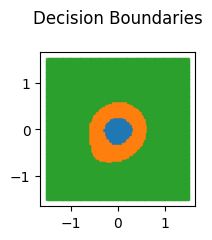

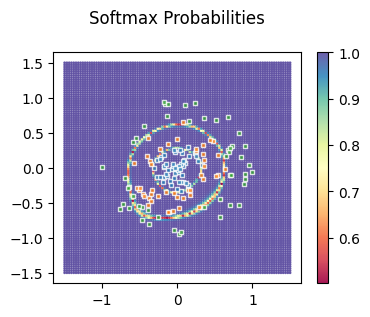

Mean stability from Shannon using softmax: 0.9843924045562744


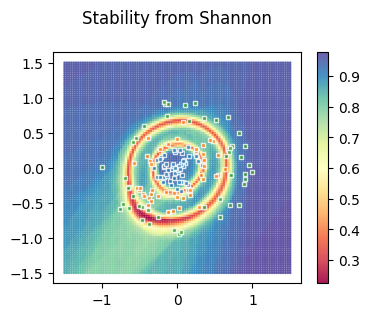

Mean Stability: 0.8633154034614563


In [19]:
plot_decision_boundary_2D(model)
plot_softmax_2D(model)
plot_stability_2D(stab) # check if stability is using only last 100 iter or not

# Comparing with Mohalanobis

## Mohalanobis method with adverarial data. 

Adversarial Data for hyperspheres don't really make sense but worth a try...

In [20]:
# get adverserial data (for hypersphere_data they are sort of just points near boundaries...)
x, y = next(iter(hypersphere_data(2, 3, 200, batch_size = 200, seed = 2)))
atk = torchattacks.FGSM(model, eps=0.05)
x_adv = atk(x,y)

# get "normal" data (points away from boundaries)
x_pos, y_pos = next(iter(hypersphere_data_away_boundary(2, 3, 200, batch_size = 200, seed = 2)))


<function matplotlib.pyplot.show(close=None, block=None)>

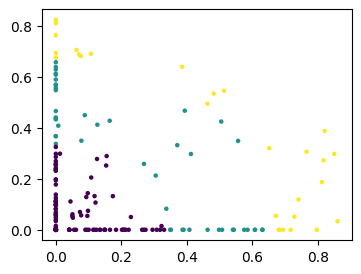

In [21]:
# visualize adversarial data sanity check

# Relabel data that may have crossed "true" decision boundary
y_adv = torch.ones(len(x_adv)).long()
y_adv[(torch.norm(x_adv, dim=1) < 1/3)] = 0
y_adv[(torch.norm(x_adv, dim=1) > 2/3)] = 2

plt.figure(figsize = (4,3))
plt.scatter(x_adv[:,0], x_adv[:,1], s=5, c=y_adv, alpha=1)
plt.show

Yeah, not sure if that was super helpful... could try adversarial_data = data near boundary.

Or try using fgsm_dataset() function to see if data still remains in first quadrant.

200it [00:00, 445.17it/s]


<function matplotlib.pyplot.show(close=None, block=None)>

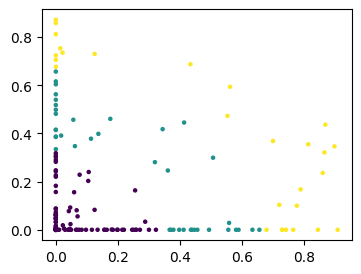

In [26]:
data = hypersphere_data(2, 3, 200, batch_size = 1, seed = 2)
adv_x, adv_y = fgsm_dataset(model, device, data, (2,), 1e-3, 200)

# Relabel data that may have crossed "true" decision boundary
adv_y = torch.ones(len(adv_x)).long()
adv_y[(torch.norm(adv_x, dim=1) < 1/3)] = 0
adv_y[(torch.norm(adv_x, dim=1) > 2/3)] = 2

plt.figure(figsize = (4,3))
plt.scatter(adv_x[:,0], adv_x[:,1], s=5, c=adv_y, alpha=1)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

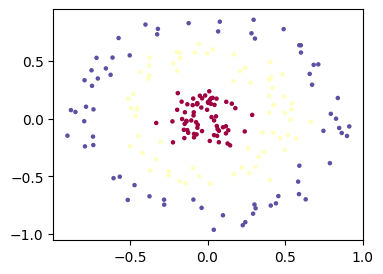

In [42]:
# visualize hypersphere_data_away_boundary data sanity check
plt.figure(figsize = (4,3))
plt.scatter(x_pos[:,0], x_pos[:,1], s=5, c=y_pos, cmap="Spectral", alpha=1)
plt.show

C:\Users\user\AppData\Local\Temp\ipykernel_23240\940002586.py:44: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  final = M_l @ alpha[0] + alpha[1]   # [x]


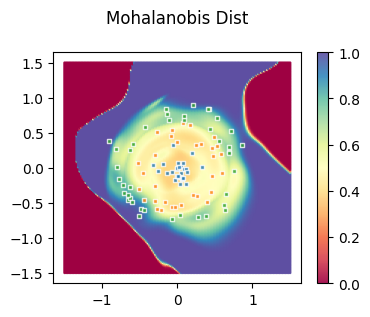

In [43]:
# use these data to train alpha
adv_alpha = compute_alpha(model, x_pos, x_adv, stats)

# generate data in input space and get mohalanobis confidence for all points
X = get_grid(input_dim = 2, num_points_per_dim=150)
moha = mohalanobis(X, model, stats, adv_alpha)

plot_moha_2D(moha, num_points_per_dim=150)

Try "adversarial data" with normal data

In [ ]:
x_pos_normal, y = next(iter(hypersphere_data(2, 3, 200, batch_size = 200, seed = 1)))

# use these data to train alpha
adv_alpha_normal = compute_alpha(model, x_pos_normal, x_adv, stats)

# generate data in input space and get mohalanobis confidence for all points
X = get_grid(input_dim = 2, num_points_per_dim=150)
moha = mohalanobis(X, model, stats, adv_alpha_normal)

plot_moha_2D(moha, num_points_per_dim=150)

## Mohalanobis method with Out Of Distribution (OOD) data

In [ ]:
# get OOD data for hypersphere_data
X = get_grid_OOD(input_dim = 2, num_points_per_dim=50) # set large number so X will be greater than 200
idx = np.random.choice(X.numpy().shape[0], size=200, replace=False)
x_ood = X.numpy()[idx]

plt.figure(figsize = (4,3))
plt.scatter(x_ood[:,0], x_ood[:,1], s=1, cmap="Spectral", alpha=1)
plt.show

In [ ]:
# get "normal" data (points away from boundaries)
x_pos, y_pos = next(iter(hypersphere_data(2, 3, 200, batch_size = 200, seed = 24)))

plt.figure(figsize = (4,3))
plt.scatter(x_pos[:,0], x_pos[:,1], s=1, cmap="Spectral", alpha=1)
plt.show

In [ ]:
# use these data to train alpha
adv_alpha = compute_alpha(model, x_pos, torch.from_numpy(x_ood), stats)

# generate data in input space and get mohalanobis confidence for all points
X = get_grid(input_dim = 2, num_points_per_dim=150)
moha = mohalanobis(X, model, stats, adv_alpha)

plot_moha_2D(moha, num_points_per_dim=150)

## Using both "adv" data and OOD data to train

Train alpha by concatenating "adv" data and OOD data as negative data, normal data as positive data

In [ ]:
x_neg = torch.cat((x_adv, torch.from_numpy(x_ood)), dim=0) 
x_pos, y = next(iter(hypersphere_data(2, 3, 400, batch_size = 400, seed = 2)))


# use these data to train alpha
alpha = compute_alpha(model, x_pos, x_neg, stats)

# generate data in input space and get mohalanobis confidence for all points
X = get_grid(input_dim = 2, num_points_per_dim=150)
moha = mohalanobis(X, model, stats, alpha)

# plot
plot_moha_2D(moha, num_points_per_dim=150)


# Training and model evaluations with noisy labeling (labeling error on boundaries)

In [ ]:
model, _, stab, _, stats = train_model(seed=737, hidden_dim=(8,16,16), n_epochs=60, amount_data=200, batch_size=20, data=hypersphere_data_noisy, num_points_per_dim=100)

In [ ]:
plot_decision_boundary_2D(model)
plot_softmax_2D(model, hypersphere_data_noisy)
plot_stability_2D(stab, hypersphere_data_noisy) # check if stability is using only last 100 iter or not

In [ ]:
# get OOD data for hypersphere_data
X = get_grid_OOD(input_dim = 2, num_points_per_dim=50) # set num_points_per_dim^2>200 since we need at least 200 pts
idx = np.random.choice(X.numpy().shape[0], size=200, replace=False)
x_ood = X.numpy()[idx]

# get adverserial data from hypersphere_data_noisy 
# (not sure it makes sense for hypersphere_data ...)
x, y = next(iter(hypersphere_data_noisy(2, 3, 200, batch_size = 200, seed = 4)))
atk = torchattacks.FGSM(model, eps=0.05)
x_adv = atk(x,y)

# concat data
x_neg = torch.cat((x_adv, torch.from_numpy(x_ood)), dim=0) 
x_pos, y = next(iter(hypersphere_data_noisy(2, 3, 400, batch_size = 400, seed = 3)))

# use these data to train alpha
alpha = compute_alpha(model, x_pos, x_neg, stats)

# generate data in input space and get mohalanobis confidence for all points
X = get_grid(input_dim = 2, num_points_per_dim=150)
moha = mohalanobis(X, model, stats, alpha)

# plot
plot_moha_2D(moha, num_points_per_dim=150)


# Compare with paper
Comparing with mahalanobis code from the "A Simple Unified Framework for Detecting
Out-of-Distribution Samples and Adversarial Attacks" paper

In [ ]:
# only run once
# !pip install oodeel --no-deps
# !pip install faiss-cpu
# !pip install datasets
import oodeel
from oodeel import methods

  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp313-cp313-win_amd64.whl.metadata (21 kB)
   ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
   ---------------------------------------- 555.1/555.1 kB 16.2 MB/s  0:00:00
Using cached aiosignal-1.4.0-py3-none-any.whl (7.5 kB)
Using cached frozenlist-1.8.0-cp313-cp313-win_amd64.whl (43 kB)

  Attempting uninstall: requests

    Found existing installation: requests 2.25.1

    Uninstalling requests-2.25.1:

      Successfully uninstalled requests-2.25.1

   --- ------------------------------------  1/12 [requests]
   --- ------------------------------------  1/12 [requests]
   --- ------------------------------------  1/12 [requests]
   --- ------------------------------------  1/12 [requests]
   ------ ---------------------------------  2/12 [propcache]
   ---------- -----------------------------  3/12 [multidict]
   ---------------- -----------------------  5/12 [dill

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
oodeel 0.4.0 requires seaborn, which is not installed.
oodeel 0.4.0 requires numpy<=1.26.4, but you have numpy 2.1.2 which is incompatible.
torchattacks 3.5.1 requires requests~=2.25.1, but you have requests 2.34.2 which is incompatible.


In [36]:
# using Mahalanobis from oodeel methods
mahalanobis = methods.Mahalanobis(eps=0.002)

data = hypersphere_data(2, 3, 100, batch_size = 100, seed = 1)
mahalanobis.fit(model, feature_layers_id=[-2], fit_dataset=data)

X = get_grid(2, 100)
i=0
scores = mahalanobis.score(X)[0]
scores

array([443522.28 , 430559.94 , 416973.2  , ...,  39088.293,  39794.008,
        40501.14 ], dtype=float32)

In [37]:
X

tensor([[-1.5000, -1.5000],
        [-1.5000, -1.4697],
        [-1.5000, -1.4394],
        ...,
        [ 1.5000,  1.4394],
        [ 1.5000,  1.4697],
        [ 1.5000,  1.5000]])

<function matplotlib.pyplot.show(close=None, block=None)>

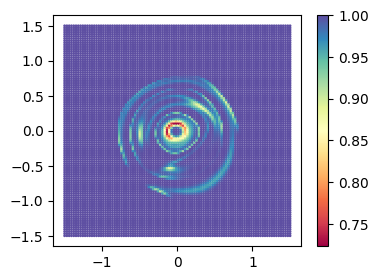

In [41]:
plt.figure(figsize = (4,3))
plt.scatter(X[:,0], X[:,1], s=1, c=torch.sigmoid(torch.from_numpy(scores)), cmap="Spectral", alpha=1)
plt.colorbar()
plt.show

Linear Circle data

In [ ]:
model, _, stab, _, stats = train_model(seed=737, hidden_dim=(8,16,16), n_epochs=60, amount_data=200, batch_size=20, data=linear_circle_data, num_points_per_dim=100)

In [ ]:
plot_decision_boundary_2D(model)
plot_softmax_2D(model, linear_circle_data)
plot_stability_2D(stab, linear_circle_data) # check if stability is using only last 100 iter or not